In [20]:
import pickle
import numpy as np
import sympy as sp
import pandas as pd
from time import time
from IPython.display import display
import matplotlib.pyplot as plt

In [7]:
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
with open('database_random_el7037.pkl', 'rb') as f:
    database = pickle.load(f)

In [5]:
from sklearn.metrics import mean_squared_error

def eval_equations(x, y, equations):
    """
    Evalúa una lista de expresiones matemáticas contra los datos y calcula el MSE para cada una.

    :param x: dataframe con las variables
    :param y: variable objetivo
    :param equations: dataframe/lista con las expresiones obtenidas
    :return: lista de tuplas (expresión, MSE) ordenadas de menor a mayor MSE.
    """
    resultados = []

    for eq in equations:
        try:
            float(eq)
            resultados.append(np.inf)
        except ValueError:
            y_pred = eval(eq, {"__builtins__": {}, "np": np, 'log': np.log, 'exp': np.exp}, x.to_dict(orient='series'))
            mse = mean_squared_error(y, y_pred)
            resultados.append(mse)

    return pd.DataFrame({'expresiones': equations, 'mse': resultados})

def get_general_metrics(y_pred, y_true):
    """
    Calcula las métricas de error RMSE, MAE y SMAPE, junto con su desviación estándar.
    :param y_pred: Arreglo con los valores predichos por la ecuación obtenida.
    :param y_true: Arreglo con los valores reales de la variable.
    :return: Retorna un diccionario, donde los values son una tupla con el valor de la métrica
             y la desviación estándar; y las keys son los strings de las métricas calculadas
             i.e. 'RMSE', 'MAE, 'SMAPE'.
    """

    # Cálculo de errores
    errores_rmse = (y_true - y_pred) ** 2
    errores_mae = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    errores_smape = (np.abs(y_true - y_pred) / denominator) * 100

    # Cálculo de métricas
    rmse = np.round(np.sqrt(np.mean(errores_rmse)), 2)
    mae = np.round(np.mean(errores_mae), 2)
    smape = np.round(np.mean(errores_smape), 2)

    # Cálculo de desviaciones estándar
    std_rmse = np.round(np.std(np.sqrt(errores_rmse)), 2)
    std_mae = np.round(np.std(errores_mae), 2)
    std_smape = np.round(np.std(errores_smape), 2)

    # Retorna un diccionario con las métricas y sus desviaciones estándar
    return {
        "RMSE": (float(rmse), float(std_rmse)),
        "MAE": (float(mae), float(std_mae)),
        "SMAPE": (float(smape), float(std_smape))
    }

## Nusselt

In [299]:
nu_train = pd.read_csv('./DATA_LIB_Degradation/df_n_train_des.txt').rename({'prandtl': 'Pr', 'S': 'Se'}, axis=1)
nu_y_train = nu_train['nusselt']
nu_train = nu_train.drop('nusselt', axis=1)

nu_val = pd.read_csv('./DATA_LIB_Degradation/df_n_val_des.txt').rename({'prandtl': 'Pr', 'S': 'Se'}, axis=1)
nu_y_val = nu_val['nusselt']
nu_val = nu_val.drop('nusselt', axis=1)

nu_test = pd.read_csv('./DATA_LIB_Degradation/df_n_test_des.txt').rename({'prandtl': 'Pr', 'S': 'Se'}, axis=1)
nu_y_test = nu_test['nusselt']
nu_test = nu_test.drop('nusselt', axis=1)

nu_train.head()

,Se,Re,Pr,SoH
0,0.280625,212.041256,0.709840,0.6363
1,0.280625,212.041256,0.707471,1.0000
2,0.280625,197.894331,0.706170,1.0000
3,0.344410,188.969448,0.708576,0.6363
4,0.344410,188.969448,0.704657,1.0000


In [282]:
nu_train = database['nu']['train'][['S', 'Re', 'prandtl', 'SoH']].rename({'prandtl': 'Pr', 'S': 'Se'}, axis=1)
nu_y_train = database['nu']['train']['nusselt']

nu_val = database['nu']['val'][['S', 'Re', 'prandtl', 'SoH']].rename({'prandtl': 'Pr', 'S': 'Se'}, axis=1)
nu_y_val = database['nu']['val']['nusselt']

nu_test = database['nu']['test'][['S', 'Re', 'prandtl', 'SoH']].rename({'prandtl': 'Pr', 'S': 'Se'}, axis=1)
nu_y_test = database['nu']['test']['nusselt']

nu_train.head()

,Se,Re,Pr,SoH
2704,0.375644,290.432906,0.701085,1.0
1476,1.430407,189.103865,0.704685,1.0
6426,0.344410,244.654992,0.707350,1.0
2327,1.134028,556.265721,0.708585,1.0
10201,1.083000,836.378658,0.706796,1.0


### Entrenamiento común

In [300]:
model = PySRRegressor(
    niterations=200,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=[],
    population_size=200,
    populations=1,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=2,
    random_state=0,
    deterministic=True,
    parallelism='serial',
    progress=False,
)

t0 = time()
model.fit(nu_train, nu_y_train)
tf = time()

print(f"Tiempo de ejecución: {tf - t0} [s]")

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!



Expressions evaluated per second: 1.610e+04
Progress: 3 / 200 total iterations (1.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.014
4           4.454e+01  7.127e-03  y = 20.017 + Se
6           4.219e+01  2.707e-02  y = (Re * 0.004608) + 17.165
9           4.190e+01  2.345e-03  y = (-5.8697 / (Se + Se)) + 23.93
13          3.739e+01  2.846e-02  y = (0.4071 + ((Se + (SoH + 1.0882)) / 0.37052)) * 2.4434
17          3.712e+01  1.794e-03  y = (Se / Pr) + (((Se + (SoH + 1.0882)) / 0.37052) * 2.443...
                                      4)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' a

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.014
4           4.372e+01  1.328e-02  y = Se + 19.115
6           3.431e+01  1.212e-01  y = (Se ^ 6.4748) + 17.789
9           3.081e+01  3.596e-02  y = 24.816 - ((1587.2 / Re) / Se)
11          2.442e+01  1.161e-01  y = 13.921 - ((1662.2 / Re) + (Se * -11.513))
13          2.421e+01  4.336e-03  y = (Se * 14.344) + (((Re * 8.2428) / 768.02) + 0.47319)
14          2.260e+01  6.877e-02  y = 17.852 - ((1542.1 / Re) + ((Se * Se) * -6.3915))
16          2.225e+01  7.941e-03  y = 17.852 - (((Se * (Se * -6.3915)) + (1542.1 / Re)) * 1....
                                      0725)
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs\20251014_173851_r7C1j9\hall_of_fame.csv
Tiempo de ejecución: 235.3325231075287 [s]


In [302]:
equations = model.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(nu_train, nu_y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
df_val = eval_equations(nu_val, nu_y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
7,17.851614 - (((Se * (Se * -6.3915296)) + (1542...,22.247461
6,17.851614 - ((1542.0804 / Re) + ((Se * Se) * -...,22.603666
5,(Se * 14.344462) + (((Re * 8.242845) / 768.024...,24.212980
4,13.920601 - ((1662.2057 / Re) + (Se * -11.5126...,24.423928
3,24.816252 - ((1587.1954 / Re) / Se),30.805044
2,(Se ** 6.4748034) + 17.78938,34.314618
1,Se + 19.114887,43.724883
0,20.01427,inf



=== VALIDATION ===


,expresiones,mse
5,(Se * 14.344462) + (((Re * 8.242845) / 768.024...,19.726254
6,17.851614 - ((1542.0804 / Re) + ((Se * Se) * -...,22.187010
7,17.851614 - (((Se * (Se * -6.3915296)) + (1542...,23.018248
4,13.920601 - ((1662.2057 / Re) + (Se * -11.5126...,25.381470
2,(Se ** 6.4748034) + 17.78938,30.157992
3,24.816252 - ((1587.1954 / Re) / Se),30.270009
1,Se + 19.114887,39.760688
0,20.01427,inf


In [303]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)
expr

0.01073*Re + 14.34*Se + 0.4732

In [296]:
Re, Se, SoH, Pr = sp.symbols('Re Se SoH Pr')
f = sp.lambdify((Re, Se, SoH, Pr), expr, 'numpy')

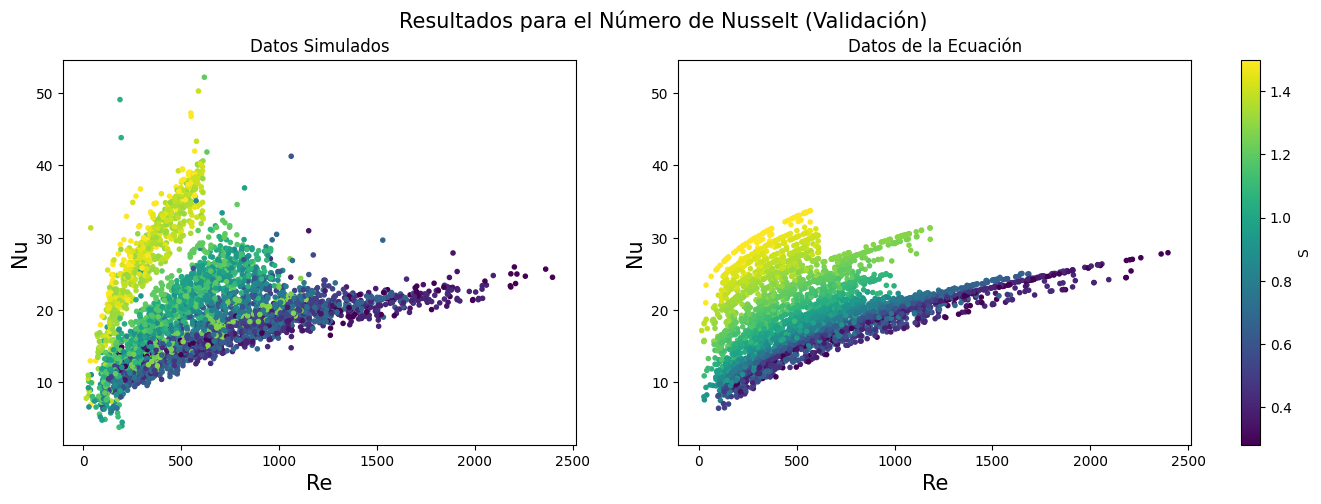

In [297]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = nu_test
y = nu_y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Validación)', fontsize=15)
plt.show()

In [298]:
y_pred = f(nu_test['Re'],
           nu_test['Se'],
           nu_test['SoH'],
           nu_test['Pr'])

results = get_general_metrics(y_pred, nu_y_test)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

RMSE = 3.91 +/- 2.73
MAE = 2.8 +/- 2.73
SMAPE = 14.19 +/- 13.3


### Entrenamiento con batching
Además, se utiliza un modelo determinista y no paralelizado para que sus resultados sean replicables

In [268]:
model_batch = PySRRegressor(
    niterations=500,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=[],
    population_size=200,
    populations=2,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=1,
    random_state=0,
    progress=False,
    parallelism='serial',
    deterministic=True,
    batching=True,
)

t0 = time()
model_batch.fit(nu_train, nu_y_train)
tf = time()

print(f"Tiempo de ejecución: {tf - t0} [s]")

[ Info: Started!



Expressions evaluated per second: 8.300e+02
Progress: 15 / 1000 total iterations (1.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.049
3           4.374e+01  1.980e-02  y = Se + 19.222
5           4.218e+01  1.809e-02  y = (Se * Se) - -18.82
7           2.858e+01  1.946e-01  y = (Re ^ 0.34312) * (Se + 1.2484)
9           2.406e+01  8.613e-02  y = (Re ^ 0.26663) * (Se + (Se - -1.926))
11          2.004e+01  9.143e-02  y = (Se * (5.4185 ^ Se)) - ((Re ^ 0.35405) * -1.5627)
13          1.914e+01  2.292e-02  y = (Se ^ 5.4185) - ((Re ^ 0.35405) * (-0.55798 - (Se + 0....
                                      5508)))
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


Tiempo de ejecución: 284.0601680278778 [s]


In [264]:
equations = model_batch.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(nu_train, nu_y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
df_val = eval_equations(nu_val, nu_y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
12,(Se * (Se * (((SoH ** 0.43041128) * Se) / 0.17...,18.820119
11,(Re ** 0.42622614) + ((Se * Se) * ((Se * SoH) ...,19.131230
10,(Re ** 0.4298373) + ((Se + -0.5862598) * (Se /...,19.495927
9,(Re ** 0.42280856) + (((Se * Se) / 0.1835025) ...,19.670521
8,(Se * ((Se * 13.376674) + -9.23664)) + (Re ** ...,19.906000
7,((Re ** 0.4298373) + 0.96939206) + ((Se + 0.20...,20.288074
6,(Re ** 0.41544437) + (Se * (Se * 7.016537)),20.792338
5,((Se + 0.20856766) ** 5.2332473) + (Re ** 0.44...,21.317952
4,(Re ** 0.41678017) * (Se - -0.5731665),24.207128
3,(Se * Re) ** 0.48619458,29.781352



=== VALIDATION ===


,expresiones,mse
12,(Se * (Se * (((SoH ** 0.43041128) * Se) / 0.17...,14.522328
10,(Re ** 0.4298373) + ((Se + -0.5862598) * (Se /...,14.890312
9,(Re ** 0.42280856) + (((Se * Se) / 0.1835025) ...,15.016270
11,(Re ** 0.42622614) + ((Se * Se) * ((Se * SoH) ...,15.051047
8,(Se * ((Se * 13.376674) + -9.23664)) + (Re ** ...,15.252448
7,((Re ** 0.4298373) + 0.96939206) + ((Se + 0.20...,15.520373
6,(Re ** 0.41544437) + (Se * (Se * 7.016537)),16.200749
5,((Se + 0.20856766) ** 5.2332473) + (Re ** 0.44...,17.020489
4,(Re ** 0.41678017) * (Se - -0.5731665),18.797678
3,(Se * Re) ** 0.48619458,24.269626


In [265]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)
expr

Re**0.423 + 5.789*Se**3*SoH**0.4304

In [266]:
Re, Se, SoH, Pr = sp.symbols('Re Se SoH Pr')
f = sp.lambdify((Re, Se, SoH, Pr), expr, 'numpy')

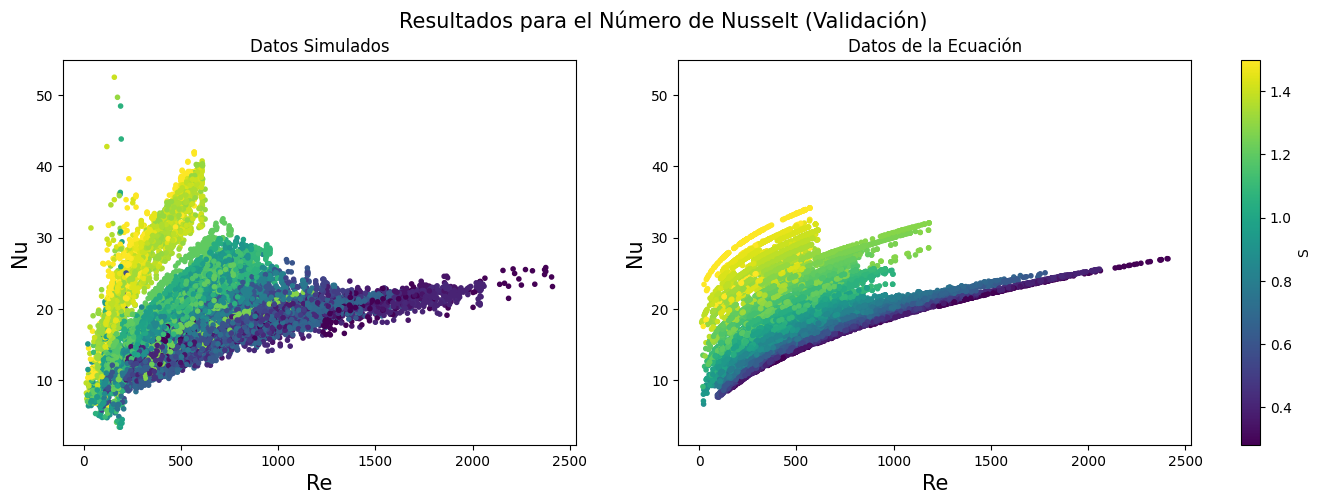

In [267]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = nu_val
y = nu_y_val

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Validación)', fontsize=15)
plt.show()

In [263]:
y_pred = f(nu_test['Re'],
           nu_test['Se'],
           nu_test['SoH'],
           nu_test['Pr'])

results = get_general_metrics(y_pred, nu_y_test)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

x_test:


NameError: name 'x_train' is not defined